# Simple TCN + Subject-Adaptive BatchNorm Statistics Only + Deterministic Baseline Training

Notes:

* Only using 10 of the 30 ADL tasks.
* This version uses a causal Temporal Convolutional Network (TCN).
* The TCN only uses current and past samples inside each window, which is better aligned with future live/streaming deployment.
* Added **BatchNorm/statistics-only adaptation**. For each held-out LOSO subject, whole task repetitions per class are used as calibration data. No model weights are optimized. Instead, only the BatchNorm running mean/variance are updated using the calibration windows, then the adapted model is evaluated on the remaining repetitions for that subject.
* Dropout is disabled during BatchNorm calibration, and all learnable weights remain frozen.
* Added deterministic seeding so baseline TCN training should be reproducible across repeated runs, subject to hardware/PyTorch limitations.


# BatchNorm / normalization-statistics-only adaptation

This notebook tests **BatchNorm/statistics-only adaptation**. It keeps all trained TCN and classifier weights fixed. During calibration, only the BatchNorm running statistics inside the TCN are updated using calibration windows from the held-out subject. This tests whether some subject-specific error is caused by feature-distribution shift rather than by incorrect learned weights.

Calibration protocol: **1/2/3 whole task repetitions/trials per class** are selected from the held-out subject by default; remaining repetitions are reserved for adapted testing.

Test: To test the BatchNorm adaptation `CALIBRATION_REPS_PER_CLASS` and `BN_ADAPT_MOMENTUM` in the settings can were changed; 1/2/3 repetitions were tested at 0.10 and 0.05 momentum.


## Imports

In [1]:
%pip install -q numpy pandas scikit-learn matplotlib torch

import os, re
# Set before torch is imported. This prevents strict CUDA deterministic-mode warnings if enabled later.
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import itertools

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import GroupShuffleSplit, LeaveOneGroupOut



# Run the mvnx_file_reader.ipynb to load MVNX files
%run mvnx_file_reader.ipynb


Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Segment labels: ['Pelvis', 'L5', 'L3', 'T12', 'T8', 'Neck', 'Head', 'RightShoulder', 'RightUpperArm', 'RightForeArm', 'RightHand', 'LeftShoulder', 'LeftUpperArm', 'LeftForeArm', 'LeftHand', 'RightUpperLeg', 'RightLowerLeg', 'RightFoot', 'RightToe', 'LeftUpperLeg', 'LeftLowerLeg', 'LeftFoot', 'LeftToe']
Segment IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
RightHand positions (first 5 frames): [[0.000326, -0.7332, 1.53858], [0.007659, -0.732989, 1.535369], [0.007659, -0.732989, 1.535369], [5.256316, 1.154359, 0.728047], [5.256684, 1.155001, 0.728414]]
normal
Data types: ['time', 'index', 'tc', 'ms', 'type', 'orientation', 'position', 'velocity', 'acceleration', 'angularVelocity', 'angularAcceleration', 'contacts', 'sensorFreeAcceleration'

### Globals

In [ ]:
# 10 ADL selection
TASK_TO_LABEL = {  # U-Limb dataset has 30 total, we're only using 10 of them for this project
    11: "lift_suitcase_to_floor",
    12: "drink_from_glass",
    13: "answer_phone",
    16: "eat_apple",
    20: "use_key_unlock",
    21: "pour_water",
    23: "brush_teeth",
    24: "open_laptop",
    28: "open_door",
    29: "place_ball_in_basket",
}

ALLOWED_TASKS = set(TASK_TO_LABEL.keys())

LEFT_LIMB_SEGS  = ["LeftUpperArm", "LeftForeArm", "LeftHand", "LeftShoulder"]
RIGHT_LIMB_SEGS = ["RightUpperArm", "RightForeArm", "RightHand", "RightShoulder"]

def segments_for_tested_limb(limb: str):
    limb = str(limb).upper()
    return LEFT_LIMB_SEGS if limb == "L" else RIGHT_LIMB_SEGS

# You may need to change DATA_ROOT to point to your local dataset path.
DATA_ROOT = "ULF_in_ADL"
# DATA_ROOT = "D:/UZH_data/ULF_in_ADL"

# Fixed experiment settings from the completed sweeps/ablations
CHANNELS = [
    "angularVelocity",
    "sensorFreeAcceleration",
]

WIN_LEN_S = 4.0   # seconds
STEP_S = 0.5      # seconds
MIN_OVERLAP_FRACTION = 0.5

# Fixed 4-arm-segment experiment only (no torso, no sweeps, no combinations)
RESULTS_BASENAME = "fixed_loso_4s_0p5s_4arm_bn_stats_adapt_seeded_fixed_2rep"
ARM_SEGMENTS = ["UpperArm", "ForeArm", "Hand", "Shoulder"]

def expand_to_bilateral_arm_segments(base_arm_segments=None):
    if base_arm_segments is None:
        base_arm_segments = ARM_SEGMENTS

    canonical_to_left = {
        "UpperArm": "LeftUpperArm",
        "ForeArm": "LeftForeArm",
        "Hand": "LeftHand",
        "Shoulder": "LeftShoulder",
    }
    canonical_to_right = {
        "UpperArm": "RightUpperArm",
        "ForeArm": "RightForeArm",
        "Hand": "RightHand",
        "Shoulder": "RightShoulder",
    }

    selected_segments = []
    for name in base_arm_segments:
        if name not in canonical_to_left:
            raise ValueError(f"Unexpected arm segment name: {name}")
        selected_segments.extend([canonical_to_left[name], canonical_to_right[name]])
    return selected_segments

SELECTED_SEGMENTS = expand_to_bilateral_arm_segments(ARM_SEGMENTS)

# Cache settings
CACHE_DIR = "cached_datasets"
USE_DATASET_CACHE = True
FORCE_REBUILD_DATASET = False

# Result saving
RESULTS_DIR = "experiment_results"

# Training settings
BATCH_SIZE_TRAIN = 128
BATCH_SIZE_EVAL = 256
EPOCHS = 20
LR = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.2
KERNEL_SIZE = 5
TCN_CHANNELS = (64, 64, 128, 128)

# Early stopping
EARLY_STOPPING_PATIENCE = 5
EARLY_STOPPING_MIN_DELTA = 0.002
VAL_SIZE = 0.20
RANDOM_STATE = 42

# Reproducibility settings
GLOBAL_SEED = 42
DETERMINISTIC_TORCH = True   # Sets cuDNN deterministic/benchmark flags.
STRICT_DETERMINISTIC_ALGORITHMS = False  # Keep False to avoid CUDA/cuBLAS warnings; seeds are still fixed.

# LOSO evaluation settings
LOSO_MAX_FOLDS = None   # Keep None to run every subject
PLOT_FIRST_FOLD_CURVES = True
SAVE_PER_FOLD_CSV = True
SAVE_PER_SUBJECT_PREDICTIONS = True
SAVE_PER_SUBJECT_REPORTS = True


# Subject-adaptation settings (Adaptation B: BatchNorm / normalization-statistics-only)
ENABLE_SUBJECT_ADAPTATION = True
CALIBRATION_REPS_PER_CLASS = 2      # two whole task repetitions/trials per class for calibration
ADAPT_BATCH_SIZE = 64
ADAPT_RANDOM_STATE = 42

# BatchNorm/statistics-only adaptation settings.
# No gradients/optimizer are used. All weights remain fixed.
# BN_CALIBRATION_PASSES controls how many forward passes over the calibration windows are used
# to update BatchNorm running_mean/running_var.
BN_CALIBRATION_PASSES = 3 # 
BN_ADAPT_MOMENTUM = 0.05  # 0.5/0.10 blends calibration stats with population stats
ADAPTATION_MODE = "batchnorm_stats_only"



### File Helpers

Helper functions to find files, parse task from filename, and extract per-segment vectors

In [3]:
# Helper functions to find and parse MVNX files
def iter_mvnx_files(root: str):
    for r, _, files in os.walk(root):
        for fn in files:
            if fn.lower().endswith(".mvnx"):
                yield os.path.join(r, fn)

# Parses participant, task, limb, and rep from filename
def parse_meta_from_filename(filepath: str):
    """
    Expected example: H01_T01_L1.mvnx OR P02_T15_R3.mvnx
    Returns dict: participant, task(int), limb('L'/'R'), rep(int)
    """
    base = os.path.basename(filepath)

    m = re.match(r"^(?P<participant>[A-Za-z]\d{2})_T(?P<task>\d{2})_(?P<limb>[LRlr])(?P<rep>\d)\.mvnx$", base)
    if not m:
        return None

    participant = m.group("participant")
    task = int(m.group("task"))
    limb = m.group("limb").upper()
    rep = int(m.group("rep"))
    return {"participant": participant, "task": task, "limb": limb, "rep": rep}


# Functions to extract frame rate and channel data from MVNX dicts
def get_frame_rate_hz(mvnx_dict) -> float:
    # MVNX stores it on subject
    fr = mvnx_dict["mvnx"]["subject"].get("frameRate", None)
    if fr is None:
        raise ValueError("frameRate not found in mvnx['mvnx']['subject']")
    return float(fr)

def _as_list(x):
    if isinstance(x, list):
        return x
    if x is None:
        return []
    return [x]

def build_segment_index_map(mvnx_dict):
    segments = _as_list(mvnx_dict["mvnx"]["subject"]["segments"]["segment"])
    return {seg["label"]: i for i, seg in enumerate(segments)}

def build_sensor_index_map(mvnx_dict):
    sensors = _as_list(mvnx_dict["mvnx"]["subject"]["sensors"]["sensor"])
    return {sensor["label"]: i for i, sensor in enumerate(sensors)}

def build_joint_index_map(mvnx_dict):
    joints = _as_list(mvnx_dict["mvnx"]["subject"]["joints"]["joint"])
    return {joint["label"]: i for i, joint in enumerate(joints)}

SEGMENT_CHANNEL_SPECS = {
    "orientation": (build_segment_index_map, 4),
    "position": (build_segment_index_map, 3),
    "velocity": (build_segment_index_map, 3),
    "acceleration": (build_segment_index_map, 3),
    "angularVelocity": (build_segment_index_map, 3),
    "angularAcceleration": (build_segment_index_map, 3),
}

SENSOR_CHANNEL_SPECS = {
    "sensorFreeAcceleration": (build_sensor_index_map, 3),
    "sensorMagneticField": (build_sensor_index_map, 3),
    "sensorOrientation": (build_sensor_index_map, 4),
}

# For joint channels we map each tested segment to the most relevant joint on that limb.
JOINT_CHANNEL_SPECS = {
    "jointAngle": 3,
    "jointAngleXZY": 3,
}

LEFT_SEGMENT_TO_JOINT = {
    "LeftShoulder": "jLeftT4Shoulder",
    "LeftUpperArm": "jLeftShoulder",
    "LeftForeArm": "jLeftElbow",
    "LeftHand": "jLeftWrist",
}

RIGHT_SEGMENT_TO_JOINT = {
    "RightShoulder": "jRightT4Shoulder",
    "RightUpperArm": "jRightShoulder",
    "RightForeArm": "jRightElbow",
    "RightHand": "jRightWrist",
}

def get_segment_joint_label(segment_label: str, limb: str) -> str:
    limb = str(limb).upper()
    mapping = LEFT_SEGMENT_TO_JOINT if limb == "L" else RIGHT_SEGMENT_TO_JOINT
    if segment_label not in mapping:
        raise KeyError(f"No joint mapping defined for segment '{segment_label}' on limb '{limb}'.")
    return mapping[segment_label]

def _slice_labeled_vector(mvnx_dict, frame_dict, channel: str, label: str, index_builder, components: int) -> np.ndarray:
    label_map = index_builder(mvnx_dict)
    if label not in label_map:
        raise KeyError(f"Label '{label}' not found for channel '{channel}'. Available labels include: {list(label_map)[:8]} ...")

    vec = frame_dict.get(channel, None)
    if vec is None:
        raise KeyError(f"Channel '{channel}' not found in this frame.")

    arr = np.asarray(vec, dtype=np.float32).ravel()
    idx = label_map[label]
    start = components * idx
    end = start + components

    if end > arr.size:
        raise ValueError(
            f"Channel '{channel}' with label '{label}' expected slice [{start}:{end}] "
            f"but frame only has {arr.size} values."
        )
    return arr[start:end]

def get_channel_vector(mvnx_dict, frame_dict, segment_label: str, channel: str, limb: str) -> np.ndarray:
    """
    Channel-aware extractor.

    Uses:
    - segment indexing for segment-level channels
    - sensor indexing for sensor-level channels
    - joint indexing for joint-angle channels
    """
    if channel in SEGMENT_CHANNEL_SPECS:
        index_builder, components = SEGMENT_CHANNEL_SPECS[channel]
        return _slice_labeled_vector(mvnx_dict, frame_dict, channel, segment_label, index_builder, components)

    if channel in SENSOR_CHANNEL_SPECS:
        index_builder, components = SENSOR_CHANNEL_SPECS[channel]
        return _slice_labeled_vector(mvnx_dict, frame_dict, channel, segment_label, index_builder, components)

    if channel in JOINT_CHANNEL_SPECS:
        joint_label = get_segment_joint_label(segment_label, limb)
        components = JOINT_CHANNEL_SPECS[channel]
        return _slice_labeled_vector(mvnx_dict, frame_dict, channel, joint_label, build_joint_index_map, components)

    raise KeyError(
        f"Unsupported channel '{channel}'. Add it to SEGMENT_CHANNEL_SPECS, "
        f"SENSOR_CHANNEL_SPECS, or JOINT_CHANNEL_SPECS."
    )

# Only keep frames where type="normal" (some files have "calibration" frames at the start that we want to ignore)
def only_normal_frames(mvnx: dict) -> list[dict]:
    frames = mvnx["mvnx"]["subject"]["frames"]["frame"]
    if isinstance(frames, dict):
        frames = [frames]
    return [fr for fr in frames if str(fr.get("type", "")).lower() == "normal"]

# Generator for start/end indices of sliding windows over N samples
def window_indices(n_samples: int, win_len: int, step: int):
    s = 0
    while s + win_len <= n_samples:
        yield s, s + win_len
        s += step


In [4]:
# quick test
sample_paths = list(iter_mvnx_files(DATA_ROOT))[:5]
print("Found files (sample):")
for p in sample_paths:
    print(" ", os.path.basename(p), parse_meta_from_filename(p))

Found files (sample):
  P17_T02_L3.mvnx {'participant': 'P17', 'task': 2, 'limb': 'L', 'rep': 3}
  P17_T24_L2.mvnx {'participant': 'P17', 'task': 24, 'limb': 'L', 'rep': 2}
  P17_T28_R3.mvnx {'participant': 'P17', 'task': 28, 'limb': 'R', 'rep': 3}
  P17_T26_L1.mvnx {'participant': 'P17', 'task': 26, 'limb': 'L', 'rep': 1}
  P17_T01_L3.mvnx {'participant': 'P17', 'task': 1, 'limb': 'L', 'rep': 3}


Helpers for mvnx frame/channel extractions

In [5]:
# Build windows for one file, returning X_win, y_win, g_win, and per-window metadata.
def windows_file_cnn(filepath: str, win_len_s, step_s, channels=None, selected_segments=None):

    if channels is None:
        channels = CHANNELS

    meta = parse_meta_from_filename(filepath)
    if meta is None or meta["task"] not in ALLOWED_TASKS:
        return None

    mvnx = load_mvnx(filepath)
    frames = only_normal_frames(mvnx)
    if len(frames) < 10:
        return None

    frame_rate = float(mvnx["mvnx"]["subject"].get("frameRate", 0))
    win_len = max(int(round(win_len_s * frame_rate)), 5)
    step = max(int(round(step_s * frame_rate)), 1)

    default_segments = segments_for_tested_limb(meta["limb"])
    if selected_segments is None:
        segments = default_segments
    else:
        selected_segments = [str(seg) for seg in selected_segments]
        available = set(default_segments)
        segments = [seg for seg in selected_segments if seg in available]
        if len(segments) == 0:
            raise ValueError(
                f"No valid segments selected for limb {meta['limb']}. "
                f"Requested: {selected_segments} | Available: {default_segments}"
            )

    N = len(frames)

    # Precompute channel arrays for each segment. The feature width depends on channel type:
    # xyz channels -> 3, quaternion channels -> 4.
    data = {}
    feature_dims = {}
    for seg in segments:
        for ch in channels:
            first_vec = get_channel_vector(mvnx, frames[0], seg, ch, meta["limb"])
            D = int(np.asarray(first_vec).size)
            arr = np.zeros((N, D), dtype=np.float32)
            arr[0] = first_vec
            for i in range(1, N):
                arr[i] = get_channel_vector(mvnx, frames[i], seg, ch, meta["limb"])
            data[(ch, seg)] = arr
            feature_dims[(ch, seg)] = D

    X_win, y_win, g_win, meta_rows = [], [], [], []
    trial_id = f"{meta['participant']}_T{meta['task']:02d}_{meta['limb']}{meta['rep']}"

    for window_number, (a, b) in enumerate(window_indices(N, win_len, step)):
        cols = []
        for seg in segments:
            for ch in channels:
                cols.append(data[(ch, seg)][a:b])   # (T,D)
        Xw = np.concatenate(cols, axis=1)          # (T, C_total)
        X_win.append(Xw)
        y_win.append(TASK_TO_LABEL[meta["task"]])
        g_win.append(meta["participant"])
        meta_rows.append({
            "participant": meta["participant"],
            "task": meta["task"],
            "task_label": TASK_TO_LABEL[meta["task"]],
            "limb": meta["limb"],
            "rep": meta["rep"],
            "trial_id": trial_id,
            "source_file": os.path.basename(filepath),
            "window_number_in_file": window_number,
            "window_start_frame": a,
            "window_end_frame": b,
        })

    if not X_win:
        return None

    return (
        np.stack(X_win, axis=0).astype(np.float32),
        np.asarray(y_win),
        np.asarray(g_win),
        pd.DataFrame(meta_rows),
    )


## Building Dataset
Building a fixed post-arm-study dataset for an **all-4-arm-segments + torso augmentation study** using:

- channels: `angularVelocity`, `sensorFreeAcceleration`
- window length: **4.0 s**
- step size: **0.5 s**

Each run keeps the tested-limb **UpperArm, ForeArm, Hand, and Shoulder** segments and then adds a combination of torso segments.


In [6]:
# Dataset caching helpers
def _safe_name(txt: str):
    txt = str(txt)
    txt = re.sub(r"[^A-Za-z0-9_.-]+", "-", txt)
    return txt.strip("-") or "default"

def canonical_segment_order(selected_segments):
    if selected_segments is None:
        return None
    return [str(seg) for seg in selected_segments]

def make_dataset_cache_path(
    root: str,
    channels,
    win_len_s: float,
    step_s: float,
    selected_segments=None,
    allowed_tasks=None,
    cache_dir: str = CACHE_DIR,
):
    os.makedirs(cache_dir, exist_ok=True)

    root_name = _safe_name(os.path.basename(os.path.normpath(root)) or "dataset")
    channel_name = _safe_name("_".join(channels))
    if selected_segments is None:
        segment_name = "default-tested-limb"
    else:
        segment_name = _safe_name("_".join(canonical_segment_order(selected_segments)))
    task_name = "alltasks" if allowed_tasks is None else _safe_name("-".join(map(str, sorted(allowed_tasks))))

    filename = (
        f"dataset_{root_name}"
        f"__ch-{channel_name}"
        f"__seg-{segment_name}"
        f"__win-{win_len_s:g}s"
        f"__step-{step_s:g}s"
        f"__tasks-{task_name}.npz"
    )
    return os.path.join(cache_dir, filename)

# Build the full dataset by iterating over all files and concatenating results.
# The returned metadata dataframe has one row per window and is needed for subject calibration splits.
def build_dataset(root: str, win_len_s, step_s, channels=None, selected_segments=None):
    if channels is None:
        channels = CHANNELS

    X_list, y_list, g_list, meta_list = [], [], [], []
    kept = 0
    skipped = 0

    for fp in iter_mvnx_files(root):
        meta = parse_meta_from_filename(fp)
        if meta is None:
            continue
        if meta["task"] not in ALLOWED_TASKS:
            continue

        try:
            out = windows_file_cnn(
                fp,
                win_len_s=win_len_s,
                step_s=step_s,
                channels=channels,
                selected_segments=selected_segments,
            )
        except Exception as e:
            skipped += 1
            print(f"Skipping {os.path.basename(fp)} due to extraction/build error: {e}")
            continue

        if out is None:
            skipped += 1
            continue

        Xw, yw, gw, mw = out
        X_list.append(Xw)
        y_list.append(yw)
        g_list.append(gw)
        meta_list.append(mw)
        kept += 1

    if not X_list:
        raise RuntimeError("No windows were built. Check parsing/task filters/DATA_ROOT.")

    X = np.concatenate(X_list, axis=0)   # (N, T, C)
    y = np.concatenate(y_list, axis=0)   # (N,)
    g = np.concatenate(g_list, axis=0)   # (N,)
    window_meta = pd.concat(meta_list, ignore_index=True)
    window_meta["global_window_index"] = np.arange(len(window_meta), dtype=int)

    print(f"Kept files: {kept} | Skipped files (allowed but failed): {skipped}")
    print("X:", X.shape, "y:", y.shape, "groups:", g.shape, "metadata:", window_meta.shape)

    return X, y, g, window_meta

def _metadata_to_cache_array(window_meta: pd.DataFrame) -> np.ndarray:
    # np.savez cannot store dataframes directly in a portable way, so store rows as object dictionaries.
    return window_meta.to_dict(orient="records")

def _metadata_from_cache_array(meta_array) -> pd.DataFrame:
    return pd.DataFrame(list(meta_array))

def load_or_build_dataset(root: str, win_len_s, step_s, channels, selected_segments=None, use_cache=True, force_rebuild=False):
    cache_path = make_dataset_cache_path(
        root=root,
        channels=channels,
        win_len_s=win_len_s,
        step_s=step_s,
        selected_segments=selected_segments,
        allowed_tasks=ALLOWED_TASKS,
        cache_dir=CACHE_DIR,
    )

    if use_cache and os.path.exists(cache_path) and not force_rebuild:
        print(f"Loading cached dataset from: {cache_path}")
        cached = np.load(cache_path, allow_pickle=True)
        if "window_meta" in cached.files:
            X = cached["X"]
            y = cached["y"]
            g = cached["groups"]
            window_meta = _metadata_from_cache_array(cached["window_meta"])
            return X, y, g, window_meta, cache_path
        else:
            print("Cached dataset does not include per-window metadata needed for calibration.")
            print("Rebuilding dataset once and saving a metadata-enabled cache...")

    print("No usable cached dataset found. Building dataset from MVNX files...")
    X, y, g, window_meta = build_dataset(
        root,
        win_len_s=win_len_s,
        step_s=step_s,
        channels=channels,
        selected_segments=selected_segments,
    )

    if use_cache:
        np.savez_compressed(
            cache_path,
            X=X.astype(np.float32),
            y=y,
            groups=g,
            window_meta=np.array(_metadata_to_cache_array(window_meta), dtype=object),
            channels=np.array(channels, dtype=object),
            selected_segments=np.array(
                canonical_segment_order(selected_segments) if selected_segments is not None else [],
                dtype=object
            ),
            win_len_s=np.array([win_len_s], dtype=np.float32),
            step_s=np.array([step_s], dtype=np.float32),
        )
        print(f"Saved dataset cache to: {cache_path}")

    return X, y, g, window_meta, cache_path

def summarize_dataset(X, y, groups, window_meta=None, prefix="Segment ablation run"):
    print(f"{prefix} dataset loaded.")
    print("Dataset shape:", X.shape)
    print("Unique subjects:", len(set(groups)))
    vals, cnts = np.unique(y, return_counts=True)
    print("Class counts:", dict(zip(vals, cnts)))
    print("Example window shape (T,C):", X[0].shape)
    if window_meta is not None:
        print("Metadata shape:", window_meta.shape)
        print("Unique trials:", window_meta["trial_id"].nunique() if "trial_id" in window_meta.columns else "N/A")


### Normalization

Different normalization from SVM

In [7]:
# IMPORTANT:
# Do NOT normalize before LOSO splitting. That would let the held-out subject
# influence scaling. Instead, fit normalization on the training fold only and
# apply it to val/test inside each fold.

def fit_channel_zscore(X: np.ndarray, eps: float = 1e-8):
    """
    Fit one global z-score per feature channel using TRAINING WINDOWS ONLY.

    X: (N, T, C)
    Returns:
        mu: (C,)
        sd: (C,)
    """
    pooled = X.reshape(-1, X.shape[-1]).astype(np.float32)
    mu = pooled.mean(axis=0)
    sd = pooled.std(axis=0)
    sd = np.maximum(sd, eps)
    return mu, sd

def apply_channel_zscore(X: np.ndarray, mu: np.ndarray, sd: np.ndarray) -> np.ndarray:
    """Apply pre-fit channel-wise z-score to (N, T, C)."""
    return ((X.astype(np.float32) - mu) / sd).astype(np.float32)

print("Normalization helpers defined.")
print("Dataset arrays (X, y, groups) are loaded later inside run_windowing_study()")
print("via load_or_build_dataset(...), one window/step configuration at a time.")


Normalization helpers defined.
Dataset arrays (X, y, groups) are loaded later inside run_windowing_study()
via load_or_build_dataset(...), one window/step configuration at a time.


### Note on dataset creation and caching

This notebook runs an **all-4-arm-segments + torso augmentation study** at a fixed **4.0 s** window and **0.5 s** step.

It uses only these IMU channels:

- `angularVelocity`
- `sensorFreeAcceleration`

The fixed arm baseline is the tested-limb 4-segment set:

- `UpperArm`
- `ForeArm`
- `Hand`
- `Shoulder`

The torso candidate segments are:

- `Pelvis`
- `L5`
- `L3`
- `T12`
- `T8`
- `Neck`

The bottom cell can run:

- an optional **4-arm baseline**
- then **all non-empty torso combinations** added on top of the 4-arm baseline

If all 6 torso segments are allowed, that gives **63 torso combinations**, plus the optional 4-arm baseline.

The dataset cache name includes both the channel set and the selected segment set, so each torso configuration gets its own `.npz` cache.


## Train and Evaluate



Train/test split by subject and encode labels

In [8]:
from sklearn.model_selection import GroupShuffleSplit, LeaveOneGroupOut
import hashlib
from collections import defaultdict
from itertools import product
from datetime import datetime

def encode_labels(y: np.ndarray):
    labels = sorted(list(set(y)))
    lab2i = {lab:i for i, lab in enumerate(labels)}
    i2lab = {i:lab for lab,i in lab2i.items()}
    y_i = np.array([lab2i[v] for v in y], dtype=np.int64)
    return labels, lab2i, i2lab, y_i

def make_grouped_train_val_split(groups_train: np.ndarray, val_size: float = VAL_SIZE, random_state: int = RANDOM_STATE):
    """
    Creates a validation split using training subjects only.
    This is used INSIDE each LOSO fold for early stopping.
    """
    unique_subjects = np.unique(groups_train)

    if len(unique_subjects) < 2:
        raise ValueError("Need at least 2 training subjects to create a validation split.")

    if len(unique_subjects) == 2:
        # Fallback: keep one subject for train and one for validation
        val_subject = unique_subjects[-1]
        val_idx = np.where(groups_train == val_subject)[0]
        train_idx = np.where(groups_train != val_subject)[0]
        return train_idx, val_idx

    gss_val = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=random_state)
    train_idx, val_idx = next(gss_val.split(np.zeros(len(groups_train)), groups=groups_train))
    return train_idx, val_idx

def hash_array(a: np.ndarray) -> str:
    h = hashlib.md5()
    h.update(a.tobytes())
    return h.hexdigest()

def report_split_integrity(name_a, X_a, g_a, idx_a, name_b, X_b, g_b, idx_b):
    overlap = set(g_a) & set(g_b)
    if overlap:
        print(f"WARNING: Subject(s) in both {name_a} and {name_b}: {overlap}")
    else:
        print(f"No subject overlap detected between {name_a} and {name_b}.")

    hashes_a = {hash_array(X_a[i]): idx_a[i] for i in range(len(X_a))}
    hashes_b = {hash_array(X_b[i]): idx_b[i] for i in range(len(X_b))}
    common = set(hashes_a.keys()) & set(hashes_b.keys())
    print(f"Identical windows in {name_a}/{name_b}: {len(common)}")
    if common:
        for h in list(common)[:5]:
            print(f"Example identical window - {name_a} idx: {hashes_a[h]} | {name_b} idx: {hashes_b[h]}")

def build_loso_splits(X, y_i, groups, max_folds=None):
    logo = LeaveOneGroupOut()
    all_loso_splits = list(logo.split(X, y_i, groups=groups))
    if max_folds is not None:
        all_loso_splits = all_loso_splits[:max_folds]
    return all_loso_splits

def window_overlap_fraction(win_len_s: float, step_s: float) -> float:
    return 1.0 - (step_s / win_len_s)

def is_valid_window_step_combo(win_len_s: float, step_s: float, min_overlap_fraction: float = MIN_OVERLAP_FRACTION) -> bool:
    if step_s <= 0 or win_len_s <= 0:
        return False
    if step_s > win_len_s:
        return False
    return window_overlap_fraction(win_len_s, step_s) >= min_overlap_fraction

def make_windowing_grid(window_lengths=None, step_sizes=None, min_overlap_fraction: float = MIN_OVERLAP_FRACTION):
    window_lengths = SWEEP_WINDOW_LENGTHS if window_lengths is None else window_lengths
    step_sizes = SWEEP_STEP_SIZES if step_sizes is None else step_sizes

    combos = []
    for win_len_s, step_s in product(window_lengths, step_sizes):
        overlap = window_overlap_fraction(win_len_s, step_s)
        if is_valid_window_step_combo(win_len_s, step_s, min_overlap_fraction=min_overlap_fraction):
            combos.append({
                "win_len_s": float(win_len_s),
                "step_s": float(step_s),
                "overlap_fraction": float(overlap),
            })
        else:
            print(f"Skipping invalid combo: win={win_len_s}, step={step_s}, overlap={overlap:.3f}")
    return combos

def ensure_results_dir(results_dir: str = RESULTS_DIR):
    os.makedirs(results_dir, exist_ok=True)
    return results_dir

def make_results_stem(study_name: str, win_len_s: float, step_s: float, results_dir: str = RESULTS_DIR):
    ensure_results_dir(results_dir)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    safe_study_name = _safe_name(study_name)

    base = f"{safe_study_name}__win-{win_len_s:g}s__step-{step_s:g}s__{timestamp}"

    # Keep filenames short enough for Windows path limits.
    max_base_len = 110
    if len(base) > max_base_len:
        name_hash = hashlib.md5(safe_study_name.encode("utf-8")).hexdigest()[:8]
        truncated = safe_study_name[:40].rstrip("-_.")
        base = f"{truncated}__{name_hash}__win-{win_len_s:g}s__step-{step_s:g}s__{timestamp}"

    if len(base) > max_base_len:
        name_hash = hashlib.md5(safe_study_name.encode("utf-8")).hexdigest()[:8]
        base = f"run__{name_hash}__w{win_len_s:g}s__s{step_s:g}s__{timestamp}"

    return os.path.join(results_dir, base)


Simple TCN dataset and model


In [9]:
import copy
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

class WindowDataset(Dataset):
    def __init__(self, X, y_int):
        # Convert (N, T, C) -> (N, C, T) for Conv1d
        self.X = torch.tensor(np.transpose(X, (0, 2, 1)), dtype=torch.float32)
        self.y = torch.tensor(y_int, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class Chomp1d(nn.Module):
    """
    Removes the extra right-side padding so the convolution is causal:
    output[t] depends only on x[:t].
    """
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size].contiguous()

class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation  # causal

        self.net = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size,
                      padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(out_channels, out_channels, kernel_size,
                      padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.downsample = nn.Conv1d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class SimpleTCN(nn.Module):
    def __init__(self, in_channels, n_classes, channels=TCN_CHANNELS, kernel_size=KERNEL_SIZE, dropout=DROPOUT):
        super().__init__()

        layers = []
        prev_channels = in_channels
        for i, out_channels in enumerate(channels):
            dilation = 2 ** i
            layers.append(
                TemporalBlock(
                    in_channels=prev_channels,
                    out_channels=out_channels,
                    kernel_size=kernel_size,
                    dilation=dilation,
                    dropout=dropout,
                )
            )
            prev_channels = out_channels

        self.tcn = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(prev_channels, n_classes)

    def forward(self, x):
        z = self.tcn(x)
        z = self.pool(z).squeeze(-1)
        return self.classifier(z)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def set_global_seed(seed: int = GLOBAL_SEED, deterministic: bool = DETERMINISTIC_TORCH, strict_algorithms: bool = STRICT_DETERMINISTIC_ALGORITHMS):
    """Set Python/NumPy/PyTorch seeds so baseline training is repeatable.

    Note: exact reproducibility can still depend on GPU, CUDA, and PyTorch versions.
    """
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    # Strict deterministic algorithms are optional. On CUDA, Conv1d backward may warn
    # unless CUBLAS_WORKSPACE_CONFIG is set before torch is imported. We set that env
    # variable in the imports cell, but keep strict mode off by default to avoid noisy
    # warnings on shared servers. Fixed seeds + seeded DataLoaders are usually enough
    # for comparing these adaptation variants.
    if strict_algorithms:
        os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except TypeError:
            # Older PyTorch versions may not support warn_only.
            torch.use_deterministic_algorithms(True)

def make_torch_generator(seed=None):
    """Create a seeded torch.Generator for deterministic DataLoader shuffling."""
    if seed is None:
        return None
    g = torch.Generator()
    g.manual_seed(int(seed))
    return g

set_global_seed(GLOBAL_SEED)
print(f"Global seed set to {GLOBAL_SEED}; deterministic_torch={DETERMINISTIC_TORCH}; strict_algorithms={STRICT_DETERMINISTIC_ALGORITHMS}")

def make_loaders(X_train, y_train_i, X_val, y_val_i, X_test, y_test_i, seed=None):
    train_ds = WindowDataset(X_train, y_train_i)
    val_ds   = WindowDataset(X_val, y_val_i)
    test_ds  = WindowDataset(X_test, y_test_i)

    train_generator = make_torch_generator(seed)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE_TRAIN, shuffle=True, drop_last=False, generator=train_generator)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE_EVAL, shuffle=False, drop_last=False)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE_EVAL, shuffle=False, drop_last=False)

    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader

def make_loader(X, y_int, batch_size=BATCH_SIZE_EVAL, shuffle=False, seed=None):
    ds = WindowDataset(X, y_int)
    generator = make_torch_generator(seed) if shuffle else None
    loader = DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False, generator=generator)
    return ds, loader

def build_model_and_training_objects(in_channels: int, y_train_i: np.ndarray, n_classes: int):
    model = SimpleTCN(
        in_channels=in_channels,
        n_classes=n_classes,
    ).to(device)

    counts = np.bincount(y_train_i, minlength=n_classes).astype(np.float32)
    w = counts.sum() / (counts + 1e-6)
    w = w / w.mean()
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32).to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    return model, criterion, optimizer

def make_weighted_ce(y_int: np.ndarray, n_classes: int):
    counts = np.bincount(y_int, minlength=n_classes).astype(np.float32)
    w = counts.sum() / (counts + 1e-6)
    w = w / w.mean()
    return nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32).to(device))

def eval_model(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            ps.append(pred)
            ys.append(yb.numpy())
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    return y_true, y_pred

def run_eval_loss_acc(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)

            pred = torch.argmax(logits, dim=1)
            ys.append(yb.cpu().numpy())
            ps.append(pred.cpu().numpy())

    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    return avg_loss, acc

def freeze_all_parameters(model):
    """Freeze all learnable weights. Adaptation B should not update any parameters."""
    for p in model.parameters():
        p.requires_grad = False
    return model

def get_batchnorm_modules(model):
    """Return all BatchNorm layers that maintain running statistics."""
    return [m for m in model.modules() if isinstance(m, nn.modules.batchnorm._BatchNorm)]

def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def adapt_batchnorm_statistics_only(
    model,
    X_cal,
    y_cal_i,
    n_classes=None,
    bn_passes: int = BN_CALIBRATION_PASSES,
    bn_momentum = BN_ADAPT_MOMENTUM,
    adapt_batch_size: int = ADAPT_BATCH_SIZE,
    adapt_seed: int | None = None,
):
    """
    Adaptation B: BatchNorm / normalization-statistics-only adaptation.

    This creates a copy of the population-trained model, freezes every learnable
    parameter, and updates only BatchNorm running_mean/running_var using calibration
    windows from the held-out subject.

    Important details:
    - No optimizer is used.
    - No gradients are computed.
    - Dropout stays disabled.
    - Conv/Linear weights and BatchNorm affine weights/biases stay fixed.
    - Only BatchNorm running statistics are updated.

    This tests whether the held-out subject's feature distribution is shifted relative
    to the population training distribution.
    """
    if n_classes is None:
        n_classes = int(np.max(y_cal_i)) + 1

    if adapt_seed is not None:
        set_global_seed(adapt_seed)

    adapted_model = copy.deepcopy(model).to(device)
    freeze_all_parameters(adapted_model)

    n_trainable = count_trainable_parameters(adapted_model)
    if n_trainable != 0:
        raise RuntimeError(f"Expected zero trainable parameters for BatchNorm-only adaptation, got {n_trainable}.")

    bn_modules = get_batchnorm_modules(adapted_model)
    if len(bn_modules) == 0:
        raise RuntimeError("No BatchNorm modules found. BatchNorm-only adaptation cannot run.")

    # Save original momenta so the model can be restored cleanly after calibration.
    original_momenta = {id(m): m.momentum for m in bn_modules}
    for m in bn_modules:
        m.momentum = bn_momentum

    _, cal_loader = make_loader(X_cal, y_cal_i, batch_size=adapt_batch_size, shuffle=True, seed=adapt_seed)
    _, cal_loader_eval = make_loader(X_cal, y_cal_i, batch_size=BATCH_SIZE_EVAL, shuffle=False)
    criterion = make_weighted_ce(y_cal_i, n_classes=n_classes)

    history = []
    initial_loss, initial_acc = run_eval_loss_acc(adapted_model, cal_loader_eval, criterion)
    history.append({
        "bn_pass": 0,
        "cal_loss": initial_loss,
        "cal_acc": initial_acc,
        "n_bn_layers": len(bn_modules),
        "bn_momentum": bn_momentum,
        "note": "before_bn_stats_update",
    })

    # Keep the whole model in eval mode first so Dropout is disabled.
    # Then set only BatchNorm modules to train mode so they update running statistics.
    adapted_model.eval()
    for m in bn_modules:
        m.train()

    with torch.no_grad():
        for pass_idx in range(1, int(bn_passes) + 1):
            for xb, _ in cal_loader:
                xb = xb.to(device)
                _ = adapted_model(xb)

            # Evaluate after each BN-statistics pass with the model fully in eval mode.
            adapted_model.eval()
            cal_loss, cal_acc = run_eval_loss_acc(adapted_model, cal_loader_eval, criterion)
            history.append({
                "bn_pass": pass_idx,
                "cal_loss": cal_loss,
                "cal_acc": cal_acc,
                "n_bn_layers": len(bn_modules),
                "bn_momentum": bn_momentum,
                "note": "after_bn_stats_update",
            })

            # Re-enable only BatchNorm stat updates for the next pass; keep Dropout disabled.
            adapted_model.eval()
            for m in bn_modules:
                m.train()

    # Restore model to evaluation mode for testing and restore original BN momentum values.
    adapted_model.eval()
    for m in bn_modules:
        m.momentum = original_momenta[id(m)]

    return adapted_model, pd.DataFrame(history)

print("TCN classes, baseline helpers, and BatchNorm/statistics-only adaptation helpers are ready.")



Using device: cuda
Global seed set to 42; deterministic_torch=True; strict_algorithms=False
TCN classes, baseline helpers, and BatchNorm/statistics-only adaptation helpers are ready.


### Train and evaluate

Loading cached dataset from: cached_datasets/dataset_ULF_in_ADL__ch-angularVelocity_sensorFreeAcceleration__seg-LeftUpperArm_RightUpperArm_LeftForeArm_RightForeArm_LeftHand_RightHand_LeftShoulder_RightShoulder__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Fixed 4-arm LOSO dataset dataset loaded.
Dataset shape: (14521, 240, 24)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148), np.str_('eat_apple'): np.int64(580), np.str_('lift_suitcase_to_floor'): np.int64(917), np.str_('open_door'): np.int64(485), np.str_('open_laptop'): np.int64(2781), np.str_('place_ball_in_basket'): np.int64(467), np.str_('pour_water'): np.int64(4606), np.str_('use_key_unlock'): np.int64(1341)}
Example window shape (T,C): (240, 24)
Metadata shape: (14521, 11)
Unique trials: 1420
Total LOSO folds to run: 25
Classes: [np.str_('answer_phone'), np.str_('brush_teeth'), np.str_('drink_from_glass'), n

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows_full_subject,n_train_subjects,n_val_subjects,...,adaptation_status,n_calibration_trials,n_calibration_windows,n_adapt_test_windows,baseline_remaining_reps_acc,baseline_remaining_reps_macro_f1,adapted_remaining_reps_acc,adapted_remaining_reps_macro_f1,adapted_minus_baseline_remaining_reps_acc,adapted_minus_baseline_remaining_reps_macro_f1
0,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,...,completed,17,98,146,0.986301,0.867870,0.993151,0.993659,0.006849,0.125790
1,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,...,completed,20,145,271,0.985240,0.989993,0.992620,0.995077,0.007380,0.005084
2,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,...,completed,20,132,247,0.963563,0.965084,0.967611,0.962916,0.004049,-0.002169
3,19,P21,4.0,0.5,0.875,10500,3525,496,19,5,...,completed,20,173,323,0.959752,0.954771,0.984520,0.984633,0.024768,0.029861
4,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,...,completed,20,126,301,0.930233,0.931020,0.946844,0.943345,0.016611,0.012325
5,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,...,completed,17,97,177,0.960452,0.868045,0.960452,0.868660,0.000000,0.000615
6,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,...,completed,20,152,336,0.955357,0.959000,0.931548,0.939339,-0.023810,-0.019661
7,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,...,completed,20,195,406,0.923645,0.895025,0.933498,0.907809,0.009852,0.012784
8,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,...,completed,20,128,280,0.942857,0.959932,0.950000,0.969400,0.007143,0.009468
9,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,...,completed,20,166,370,0.894595,0.900864,0.921622,0.915423,0.027027,0.014559



LOSO SUMMARY
Baseline full held-out-subject window-level accuracy: 0.8232
Baseline full held-out-subject window-level macro F1: 0.8202
Baseline mean fold accuracy: 0.8529 ± 0.1334
Baseline mean fold macro F1: 0.8312 ± 0.1619

ADAPTATION B SUMMARY: BatchNorm/statistics-only adaptation
Completed adapted folds: 25/25
Mean baseline accuracy on remaining non-calibration reps: 0.8493
Mean adapted accuracy on remaining non-calibration reps:  0.8620
Mean accuracy gain: +0.0126
Mean baseline macro F1 on remaining reps: 0.8146
Mean adapted macro F1 on remaining reps:  0.8285
Mean macro-F1 gain: +0.0139
Saved summary CSV: experiment_results/fixed_loso_4s_0p5s_4arm_bn_stats_adapt_s__83d9f8cb__win-4s__step-0.5s__20260506_155627__summary.csv
Saved per-fold CSV: experiment_results/fixed_loso_4s_0p5s_4arm_bn_stats_adapt_s__83d9f8cb__win-4s__step-0.5s__20260506_155627__folds.csv
Saved all-subject prediction CSV: experiment_results/fixed_loso_4s_0p5s_4arm_bn_stats_adapt_s__83d9f8cb__win-4s__step-0.5s__

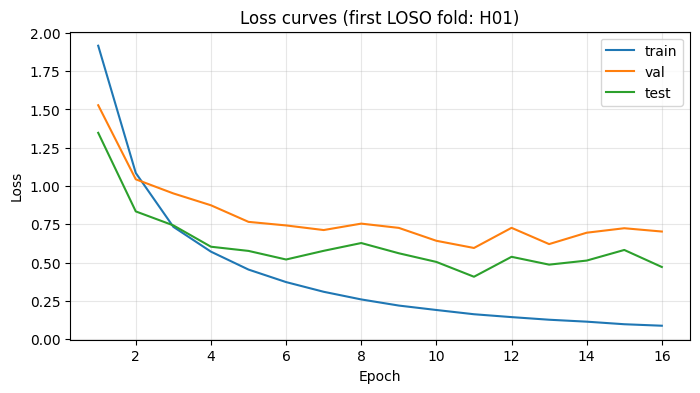

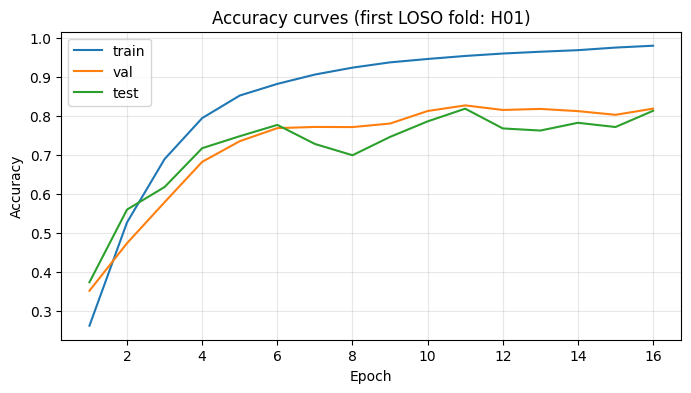


Fixed LOSO experiment complete.


,study_name,win_len_s,step_s,overlap_fraction,channels_used,selected_segments,n_total_windows,n_subjects,n_classes,cache_path,...,adapt_mean_baseline_remaining_reps_acc,adapt_mean_adapted_remaining_reps_acc,adapt_mean_gain_acc,adapt_mean_baseline_remaining_reps_macro_f1,adapt_mean_adapted_remaining_reps_macro_f1,adapt_mean_gain_macro_f1,adapt_overall_window_acc_remaining_reps,adapt_overall_window_macro_f1_remaining_reps,arm_segments,dataset_cache_path
0,fixed_loso_4s_0p5s_4arm_bn_stats_adapt_seeded_...,4.0,0.5,0.875,angularVelocity|sensorFreeAcceleration,LeftUpperArm|RightUpperArm|LeftForeArm|RightFo...,14521,25,10,cached_datasets/dataset_ULF_in_ADL__ch-angular...,...,0.849342,0.861987,0.012644,0.81461,0.828541,0.013931,0.836621,0.826779,UpperArm|ForeArm|Hand|Shoulder,cached_datasets/dataset_ULF_in_ADL__ch-angular...



Subjects ranked by baseline LOSO test accuracy:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows_full_subject,n_train_subjects,n_val_subjects,...,adaptation_status,n_calibration_trials,n_calibration_windows,n_adapt_test_windows,baseline_remaining_reps_acc,baseline_remaining_reps_macro_f1,adapted_remaining_reps_acc,adapted_remaining_reps_macro_f1,adapted_minus_baseline_remaining_reps_acc,adapted_minus_baseline_remaining_reps_macro_f1
0,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,...,completed,17,98,146,0.986301,0.867870,0.993151,0.993659,0.006849,0.125790
1,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,...,completed,20,145,271,0.985240,0.989993,0.992620,0.995077,0.007380,0.005084
2,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,...,completed,20,132,247,0.963563,0.965084,0.967611,0.962916,0.004049,-0.002169
3,19,P21,4.0,0.5,0.875,10500,3525,496,19,5,...,completed,20,173,323,0.959752,0.954771,0.984520,0.984633,0.024768,0.029861
4,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,...,completed,20,126,301,0.930233,0.931020,0.946844,0.943345,0.016611,0.012325
5,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,...,completed,17,97,177,0.960452,0.868045,0.960452,0.868660,0.000000,0.000615
6,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,...,completed,20,152,336,0.955357,0.959000,0.931548,0.939339,-0.023810,-0.019661
7,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,...,completed,20,195,406,0.923645,0.895025,0.933498,0.907809,0.009852,0.012784
8,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,...,completed,20,128,280,0.942857,0.959932,0.950000,0.969400,0.007143,0.009468
9,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,...,completed,20,166,370,0.894595,0.900864,0.921622,0.915423,0.027027,0.014559


Best held-out subject: P19
Worst held-out subject: P08

Classification report for best subject baseline:


...

,test_subject,evaluation,label_or_avg,precision,recall,f1-score,support
0,P08,adapted_remaining_reps,answer_phone,0.000000,0.000000,0.000000,0.000000
1,P08,adapted_remaining_reps,brush_teeth,0.000000,0.000000,0.000000,0.000000
2,P08,adapted_remaining_reps,drink_from_glass,1.000000,0.390244,0.561404,41.000000
3,P08,adapted_remaining_reps,eat_apple,0.000000,0.000000,0.000000,2.000000
4,P08,adapted_remaining_reps,lift_suitcase_to_floor,1.000000,0.805556,0.892308,36.000000
5,P08,adapted_remaining_reps,open_door,0.000000,0.000000,0.000000,3.000000
6,P08,adapted_remaining_reps,open_laptop,0.000000,0.000000,0.000000,0.000000
7,P08,adapted_remaining_reps,place_ball_in_basket,0.000000,0.000000,0.000000,0.000000
8,P08,adapted_remaining_reps,pour_water,0.000000,0.000000,0.000000,0.000000
9,P08,adapted_remaining_reps,use_key_unlock,0.700000,0.368421,0.482759,19.000000



Baseline per-subject / per-class breakdown:


,test_subject,true_label,n_windows,n_correct,n_errors,class_accuracy
1,H01,brush_teeth,43,27,16,0.627907
8,H01,pour_water,135,86,49,0.637037
3,H01,eat_apple,23,17,6,0.739130
9,H01,use_key_unlock,22,18,4,0.818182
0,H01,answer_phone,30,26,4,0.866667
...,...,...,...,...,...,...
239,P30,brush_teeth,35,33,2,0.942857
244,P30,open_laptop,96,96,0,1.000000
238,P30,answer_phone,17,17,0,1.000000
243,P30,open_door,17,17,0,1.000000



Subject-adaptation summary by fold:


,test_subject,baseline_full_subject_acc,baseline_remaining_reps_acc,adapted_remaining_reps_acc,adapted_minus_baseline_remaining_reps_acc,baseline_remaining_reps_macro_f1,adapted_remaining_reps_macro_f1,adapted_minus_baseline_remaining_reps_macro_f1,n_calibration_trials,n_calibration_windows,n_adapt_test_windows,adaptation_status
10,P08,0.456929,0.435644,0.514851,0.079208,0.141818,0.193647,0.051829,20,166,101,completed
9,P06,0.747727,0.752708,0.826715,0.074007,0.752819,0.784348,0.031529,20,326,554,completed
13,P12,0.892038,0.895050,0.938614,0.043564,0.903701,0.943707,0.040005,20,236,505,completed
5,P02,0.858187,0.873239,0.903756,0.030516,0.883476,0.917112,0.033637,20,258,426,completed
8,P05,0.528592,0.515050,0.545151,0.030100,0.517528,0.533956,0.016428,20,467,897,completed
7,P04,0.919776,0.894595,0.921622,0.027027,0.900864,0.915423,0.014559,20,166,370,completed
18,P21,0.955645,0.959752,0.984520,0.024768,0.954771,0.984633,0.029861,20,173,323,completed
1,H02,0.902256,0.901099,0.923077,0.021978,0.793162,0.814109,0.020947,19,84,182,completed
11,P09,0.762983,0.731250,0.750000,0.018750,0.737129,0.780767,0.043638,20,271,480,completed
2,H03,0.950820,0.930233,0.946844,0.016611,0.931020,0.943345,0.012325,20,126,301,completed


In [10]:
from sklearn.metrics import f1_score, classification_report

def select_calibration_indices_reps_per_class(
    test_idx: np.ndarray,
    y_labels: np.ndarray,
    window_meta: pd.DataFrame,
    reps_per_class: int = CALIBRATION_REPS_PER_CLASS,
    random_state: int = ADAPT_RANDOM_STATE,
):
    """
    Select two whole task repetitions/trials per class from the held-out subject as calibration data.

    Important: this selects entire files/trials, not random overlapping windows. This avoids leakage where
    neighboring heavily-overlapped windows from the same repetition appear in both calibration and testing.
    """
    if window_meta is None:
        raise ValueError("window_meta is required for subject adaptation. Rebuild/load dataset with metadata enabled.")

    rng = np.random.default_rng(random_state)
    meta_test = window_meta.iloc[test_idx].copy()
    meta_test["global_window_index"] = test_idx
    meta_test["label"] = y_labels[test_idx]

    required_cols = {"task_label", "trial_id", "global_window_index"}
    missing = required_cols - set(meta_test.columns)
    if missing:
        raise ValueError(f"window_meta is missing required columns for calibration split: {missing}")

    calibration_global_indices = []
    selected_trials = []

    for label in sorted(meta_test["label"].unique()):
        label_trials = (
            meta_test.loc[meta_test["label"] == label, ["trial_id", "task", "limb", "rep", "source_file"]]
            .drop_duplicates()
            .sort_values(by=["task", "limb", "rep", "trial_id"])
            .reset_index(drop=True)
        )
        if len(label_trials) == 0:
            continue

        # Deterministic but not always just the first alphabetical trial: shuffle with fixed seed, then take reps_per_class.
        trial_order = np.arange(len(label_trials))
        rng.shuffle(trial_order)
        chosen_rows = label_trials.iloc[trial_order[:reps_per_class]]

        for _, row in chosen_rows.iterrows():
            trial_id = row["trial_id"]
            trial_window_indices = meta_test.loc[meta_test["trial_id"] == trial_id, "global_window_index"].to_numpy()
            calibration_global_indices.extend(trial_window_indices.tolist())
            selected_trials.append({
                "label": label,
                "trial_id": trial_id,
                "task": row.get("task", None),
                "limb": row.get("limb", None),
                "rep": row.get("rep", None),
                "source_file": row.get("source_file", None),
                "n_calibration_windows": len(trial_window_indices),
            })

    calibration_global_indices = np.array(sorted(set(calibration_global_indices)), dtype=int)
    adapt_test_global_indices = np.array(sorted(set(test_idx) - set(calibration_global_indices)), dtype=int)

    selected_trials_df = pd.DataFrame(selected_trials)
    return calibration_global_indices, adapt_test_global_indices, selected_trials_df

def _global_to_fold_positions(global_indices: np.ndarray, fold_global_indices: np.ndarray) -> np.ndarray:
    pos_map = {int(global_idx): pos for pos, global_idx in enumerate(fold_global_indices)}
    return np.array([pos_map[int(idx)] for idx in global_indices], dtype=int)

def run_loso_experiment(
    X,
    y,
    groups,
    study_name: str,
    win_len_s: float,
    step_s: float,
    window_meta=None,
    channels_used=None,
    selected_segments=None,
    plot_first_fold_curves: bool = PLOT_FIRST_FOLD_CURVES,
    loso_max_folds=LOSO_MAX_FOLDS,
    save_per_fold_csv: bool = SAVE_PER_FOLD_CSV,
    save_per_subject_predictions: bool = SAVE_PER_SUBJECT_PREDICTIONS,
    save_per_subject_reports: bool = SAVE_PER_SUBJECT_REPORTS,
    results_dir: str = RESULTS_DIR,
    enable_subject_adaptation: bool = ENABLE_SUBJECT_ADAPTATION,
    calibration_reps_per_class: int = CALIBRATION_REPS_PER_CLASS,
):
    labels, lab2i, i2lab, y_i = encode_labels(y)
    all_loso_splits = build_loso_splits(X, y_i, groups, max_folds=loso_max_folds)

    print(f"Total LOSO folds to run: {len(all_loso_splits)}")
    print("Classes:", labels)
    print("Subjects:", sorted(np.unique(groups)))
    if enable_subject_adaptation:
        print(f"Subject adaptation enabled: BatchNorm/statistics-only adaptation with {calibration_reps_per_class} repetition(s) per class.")

    fold_rows = []
    prediction_rows = []
    adaptation_trial_rows = []
    adaptation_history_rows = []
    per_subject_reports = {}
    per_subject_adapt_reports = {}
    all_y_true = []
    all_y_pred = []
    all_y_true_adapt = []
    all_y_pred_adapt = []
    first_fold_history = None

    results_stem = make_results_stem(
        study_name=study_name,
        win_len_s=win_len_s,
        step_s=step_s,
        results_dir=results_dir,
    )

    for fold_idx, (trainval_idx, test_idx) in enumerate(all_loso_splits, start=1):
        held_out_subject = np.unique(groups[test_idx])
        if len(held_out_subject) != 1:
            raise RuntimeError("LOSO fold should contain exactly one held-out subject.")
        held_out_subject = held_out_subject[0]

        print("=" * 90)
        print(f"LOSO fold {fold_idx}/{len(all_loso_splits)} | test subject: {held_out_subject}")

        # Deterministic fold-level seed: controls model initialization, PyTorch RNG, and DataLoader shuffling.
        fold_seed = GLOBAL_SEED + fold_idx
        set_global_seed(fold_seed)
        print(f"Fold seed: {fold_seed}")

        X_trainval_raw, X_test_raw = X[trainval_idx], X[test_idx]
        y_trainval_i, y_test_i = y_i[trainval_idx], y_i[test_idx]
        y_test_labels = y[test_idx]
        g_trainval, g_test = groups[trainval_idx], groups[test_idx]

        train_sub_idx, val_sub_idx = make_grouped_train_val_split(
            g_trainval,
            val_size=VAL_SIZE,
            random_state=RANDOM_STATE
        )

        X_train_raw, X_val_raw = X_trainval_raw[train_sub_idx], X_trainval_raw[val_sub_idx]
        y_train_i, y_val_i = y_trainval_i[train_sub_idx], y_trainval_i[val_sub_idx]
        g_train, g_val = g_trainval[train_sub_idx], g_trainval[val_sub_idx]

        print(f"Train subjects: {sorted(np.unique(g_train))}")
        print(f"Val subjects:   {sorted(np.unique(g_val))}")
        print(f"Test subject:   {sorted(np.unique(g_test))}")

        mu, sd = fit_channel_zscore(X_train_raw)
        X_train = apply_channel_zscore(X_train_raw, mu, sd)
        X_val   = apply_channel_zscore(X_val_raw, mu, sd)
        X_test  = apply_channel_zscore(X_test_raw, mu, sd)

        report_split_integrity(
            "train", X_train, g_train, trainval_idx[train_sub_idx],
            "val", X_val, g_val, trainval_idx[val_sub_idx]
        )
        report_split_integrity(
            "train", X_train, g_train, trainval_idx[train_sub_idx],
            "test", X_test, g_test, test_idx
        )
        report_split_integrity(
            "val", X_val, g_val, trainval_idx[val_sub_idx],
            "test", X_test, g_test, test_idx
        )

        train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = make_loaders(
            X_train, y_train_i, X_val, y_val_i, X_test, y_test_i, seed=fold_seed + 10_000
        )

        model, criterion, optimizer = build_model_and_training_objects(
            in_channels=train_ds.X.shape[1],
            y_train_i=y_train_i,
            n_classes=len(labels),
        )

        train_losses, val_losses, test_losses = [], [], []
        train_accs, val_accs, test_accs = [], [], []

        epochs_ran = 0
        best_val_acc = -1.0
        best_state = None
        patience_counter = 0

        for epoch in range(1, EPOCHS + 1):
            epochs_ran = epoch
            model.train()
            total_loss = 0.0
            ys, ps = [], []

            for xb, yb in train_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                optimizer.zero_grad()
                logits = model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

                total_loss += loss.item() * xb.size(0)
                pred = torch.argmax(logits, dim=1)
                ys.append(yb.cpu().numpy())
                ps.append(pred.detach().cpu().numpy())

            train_loss = total_loss / len(train_loader.dataset)
            train_acc = accuracy_score(np.concatenate(ys), np.concatenate(ps))

            val_loss, val_acc = run_eval_loss_acc(model, val_loader, criterion)
            test_loss, test_acc = run_eval_loss_acc(model, test_loader, criterion)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            test_losses.append(test_loss)
            train_accs.append(train_acc)
            val_accs.append(val_acc)
            test_accs.append(test_acc)

            print(
                f"Epoch {epoch:02d} | "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
                f"test_loss={test_loss:.4f} test_acc={test_acc:.4f}"
            )

            improvement = val_acc - best_val_acc
            if improvement > EARLY_STOPPING_MIN_DELTA:
                best_val_acc = val_acc
                best_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                print(
                    f"  No validation improvement greater than {EARLY_STOPPING_MIN_DELTA:.4f}. "
                    f"Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}"
                )
                if patience_counter >= EARLY_STOPPING_PATIENCE:
                    print(f"Early stopping triggered at epoch {epoch}.")
                    break

        if best_state is not None:
            model.load_state_dict(best_state)

        # Baseline evaluation on the full held-out subject.
        y_true_fold, y_pred_fold = eval_model(model, test_loader)
        fold_acc = accuracy_score(y_true_fold, y_pred_fold)
        fold_macro_f1 = f1_score(y_true_fold, y_pred_fold, average="macro", zero_division=0)

        report_dict = classification_report(
            y_true_fold,
            y_pred_fold,
            labels=np.arange(len(labels)),
            target_names=labels,
            output_dict=True,
            zero_division=0,
        )
        report_df = pd.DataFrame(report_dict).transpose().reset_index().rename(columns={"index": "label_or_avg"})
        report_df.insert(0, "test_subject", held_out_subject)
        report_df.insert(1, "evaluation", "baseline_full_subject")
        per_subject_reports[held_out_subject] = report_df

        pred_df = pd.DataFrame({
            "fold": fold_idx,
            "test_subject": held_out_subject,
            "evaluation": "baseline_full_subject",
            "window_global_index": test_idx,
            "true_label": [i2lab[i] for i in y_true_fold],
            "pred_label": [i2lab[i] for i in y_pred_fold],
            "true_label_int": y_true_fold,
            "pred_label_int": y_pred_fold,
            "correct": y_true_fold == y_pred_fold,
        })
        prediction_rows.append(pred_df)

        # Optional Adaptation B: BatchNorm/statistics-only update using whole trial/repetition calibration data.
        adaptation_status = "not_run"
        n_calibration_windows = 0
        n_adapt_test_windows = 0
        baseline_adapt_test_acc = np.nan
        baseline_adapt_test_macro_f1 = np.nan
        adapted_test_acc = np.nan
        adapted_test_macro_f1 = np.nan
        n_selected_calibration_trials = 0

        if enable_subject_adaptation:
            try:
                cal_global_idx, adapt_test_global_idx, selected_trials_df = select_calibration_indices_reps_per_class(
                    test_idx=test_idx,
                    y_labels=y,
                    window_meta=window_meta,
                    reps_per_class=calibration_reps_per_class,
                    random_state=ADAPT_RANDOM_STATE + fold_idx,
                )
                n_calibration_windows = len(cal_global_idx)
                n_adapt_test_windows = len(adapt_test_global_idx)
                n_selected_calibration_trials = len(selected_trials_df)

                if n_calibration_windows == 0 or n_adapt_test_windows == 0:
                    adaptation_status = "skipped_empty_calibration_or_test"
                    print(f"Skipping adaptation for {held_out_subject}: calibration windows={n_calibration_windows}, adapted-test windows={n_adapt_test_windows}")
                else:
                    cal_pos = _global_to_fold_positions(cal_global_idx, test_idx)
                    adapt_test_pos = _global_to_fold_positions(adapt_test_global_idx, test_idx)

                    X_cal, y_cal_i = X_test[cal_pos], y_test_i[cal_pos]
                    X_adapt_test, y_adapt_test_i = X_test[adapt_test_pos], y_test_i[adapt_test_pos]

                    _, cal_loader_eval = make_loader(X_cal, y_cal_i, batch_size=BATCH_SIZE_EVAL, shuffle=False)
                    _, adapt_test_loader = make_loader(X_adapt_test, y_adapt_test_i, batch_size=BATCH_SIZE_EVAL, shuffle=False)

                    # Baseline performance on the exact same non-calibration windows used for adapted testing.
                    y_true_base_adapt_test, y_pred_base_adapt_test = eval_model(model, adapt_test_loader)
                    baseline_adapt_test_acc = accuracy_score(y_true_base_adapt_test, y_pred_base_adapt_test)
                    baseline_adapt_test_macro_f1 = f1_score(y_true_base_adapt_test, y_pred_base_adapt_test, average="macro", zero_division=0)

                    adapted_model, adapt_history_df = adapt_batchnorm_statistics_only(
                        model=model,
                        X_cal=X_cal,
                        y_cal_i=y_cal_i,
                        n_classes=len(labels),
                        bn_passes=BN_CALIBRATION_PASSES,
                        bn_momentum=BN_ADAPT_MOMENTUM,
                        adapt_batch_size=ADAPT_BATCH_SIZE,
                        adapt_seed=GLOBAL_SEED + 100_000 + fold_idx,
                    )

                    y_true_adapt, y_pred_adapt = eval_model(adapted_model, adapt_test_loader)
                    adapted_test_acc = accuracy_score(y_true_adapt, y_pred_adapt)
                    adapted_test_macro_f1 = f1_score(y_true_adapt, y_pred_adapt, average="macro", zero_division=0)
                    adaptation_status = "completed"

                    selected_trials_df = selected_trials_df.copy()
                    selected_trials_df.insert(0, "fold", fold_idx)
                    selected_trials_df.insert(1, "test_subject", held_out_subject)
                    adaptation_trial_rows.append(selected_trials_df)

                    adapt_history_df = adapt_history_df.copy()
                    adapt_history_df.insert(0, "fold", fold_idx)
                    adapt_history_df.insert(1, "test_subject", held_out_subject)
                    adaptation_history_rows.append(adapt_history_df)

                    adapt_report_dict = classification_report(
                        y_true_adapt,
                        y_pred_adapt,
                        labels=np.arange(len(labels)),
                        target_names=labels,
                        output_dict=True,
                        zero_division=0,
                    )
                    adapt_report_df = pd.DataFrame(adapt_report_dict).transpose().reset_index().rename(columns={"index": "label_or_avg"})
                    adapt_report_df.insert(0, "test_subject", held_out_subject)
                    adapt_report_df.insert(1, "evaluation", "adapted_remaining_reps")
                    per_subject_adapt_reports[held_out_subject] = adapt_report_df

                    adapt_pred_df = pd.DataFrame({
                        "fold": fold_idx,
                        "test_subject": held_out_subject,
                        "evaluation": "adapted_remaining_reps",
                        "window_global_index": adapt_test_global_idx,
                        "true_label": [i2lab[i] for i in y_true_adapt],
                        "pred_label": [i2lab[i] for i in y_pred_adapt],
                        "true_label_int": y_true_adapt,
                        "pred_label_int": y_pred_adapt,
                        "correct": y_true_adapt == y_pred_adapt,
                    })
                    prediction_rows.append(adapt_pred_df)

                    base_same_test_pred_df = pd.DataFrame({
                        "fold": fold_idx,
                        "test_subject": held_out_subject,
                        "evaluation": "baseline_remaining_reps_only",
                        "window_global_index": adapt_test_global_idx,
                        "true_label": [i2lab[i] for i in y_true_base_adapt_test],
                        "pred_label": [i2lab[i] for i in y_pred_base_adapt_test],
                        "true_label_int": y_true_base_adapt_test,
                        "pred_label_int": y_pred_base_adapt_test,
                        "correct": y_true_base_adapt_test == y_pred_base_adapt_test,
                    })
                    prediction_rows.append(base_same_test_pred_df)

                    all_y_true_adapt.append(y_true_adapt)
                    all_y_pred_adapt.append(y_pred_adapt)

                    print(
                        f"BatchNorm adaptation complete | subject={held_out_subject} | "
                        f"cal_windows={n_calibration_windows} | test_windows={n_adapt_test_windows} | "
                        f"baseline_same_test_acc={baseline_adapt_test_acc:.4f} | "
                        f"bn_adapted_acc={adapted_test_acc:.4f}"
                    )

            except Exception as e:
                adaptation_status = f"error: {e}"
                print(f"WARNING: Subject adaptation failed for {held_out_subject}: {e}")

        fold_rows.append({
            "fold": fold_idx,
            "test_subject": held_out_subject,
            "win_len_s": win_len_s,
            "step_s": step_s,
            "overlap_fraction": window_overlap_fraction(win_len_s, step_s),
            "n_train_windows": len(train_ds),
            "n_val_windows": len(val_ds),
            "n_test_windows_full_subject": len(test_ds),
            "n_train_subjects": len(np.unique(g_train)),
            "n_val_subjects": len(np.unique(g_val)),
            "epochs_ran": epochs_ran,
            "best_val_acc": best_val_acc,
            "baseline_full_subject_acc": fold_acc,
            "baseline_full_subject_macro_f1": fold_macro_f1,
            "adaptation_status": adaptation_status,
            "n_calibration_trials": n_selected_calibration_trials,
            "n_calibration_windows": n_calibration_windows,
            "n_adapt_test_windows": n_adapt_test_windows,
            "baseline_remaining_reps_acc": baseline_adapt_test_acc,
            "baseline_remaining_reps_macro_f1": baseline_adapt_test_macro_f1,
            "adapted_remaining_reps_acc": adapted_test_acc,
            "adapted_remaining_reps_macro_f1": adapted_test_macro_f1,
            "adapted_minus_baseline_remaining_reps_acc": adapted_test_acc - baseline_adapt_test_acc if np.isfinite(adapted_test_acc) and np.isfinite(baseline_adapt_test_acc) else np.nan,
            "adapted_minus_baseline_remaining_reps_macro_f1": adapted_test_macro_f1 - baseline_adapt_test_macro_f1 if np.isfinite(adapted_test_macro_f1) and np.isfinite(baseline_adapt_test_macro_f1) else np.nan,
        })

        all_y_true.append(y_true_fold)
        all_y_pred.append(y_pred_fold)

        if save_per_subject_predictions:
            pred_csv = f"{results_stem}__subject-{held_out_subject}__predictions.csv"
            pd.concat([df for df in prediction_rows if ("test_subject" in df.columns and (df["test_subject"] == held_out_subject).all())], ignore_index=True).to_csv(pred_csv, index=False)
            print(f"Saved subject prediction CSV: {pred_csv}")

        if save_per_subject_reports:
            report_csv = f"{results_stem}__subject-{held_out_subject}__report.csv"
            report_df.to_csv(report_csv, index=False)
            print(f"Saved subject baseline report CSV: {report_csv}")
            if held_out_subject in per_subject_adapt_reports:
                adapt_report_csv = f"{results_stem}__subject-{held_out_subject}__adapted_report.csv"
                per_subject_adapt_reports[held_out_subject].to_csv(adapt_report_csv, index=False)
                print(f"Saved subject adapted report CSV: {adapt_report_csv}")

        if first_fold_history is None:
            first_fold_history = {
                "epochs_ran": epochs_ran,
                "train_losses": train_losses.copy(),
                "val_losses": val_losses.copy(),
                "test_losses": test_losses.copy(),
                "train_accs": train_accs.copy(),
                "val_accs": val_accs.copy(),
                "test_accs": test_accs.copy(),
                "subject": held_out_subject,
            }

        print(
            f"Fold {fold_idx} complete | subject={held_out_subject} | "
            f"baseline_full_acc={fold_acc:.4f} | baseline_full_macro_f1={fold_macro_f1:.4f} | "
            f"adapted_remaining_acc={adapted_test_acc if np.isfinite(adapted_test_acc) else np.nan:.4f}"
        )

    results_df = pd.DataFrame(fold_rows)
    display(results_df.sort_values(by="baseline_full_subject_acc", ascending=False).reset_index(drop=True))

    all_y_true = np.concatenate(all_y_true)
    all_y_pred = np.concatenate(all_y_pred)
    all_predictions_df = pd.concat(prediction_rows, ignore_index=True) if prediction_rows else pd.DataFrame()

    overall_acc = accuracy_score(all_y_true, all_y_pred)
    overall_macro_f1 = f1_score(all_y_true, all_y_pred, average="macro", zero_division=0)
    mean_fold_acc = results_df["baseline_full_subject_acc"].mean()
    std_fold_acc = results_df["baseline_full_subject_acc"].std(ddof=1) if len(results_df) > 1 else 0.0
    mean_fold_macro_f1 = results_df["baseline_full_subject_macro_f1"].mean()
    std_fold_macro_f1 = results_df["baseline_full_subject_macro_f1"].std(ddof=1) if len(results_df) > 1 else 0.0
    mean_epochs_ran = results_df["epochs_ran"].mean()
    mean_best_val_acc = results_df["best_val_acc"].mean()

    # Adapted summary uses only remaining non-calibration repetitions and should be compared against baseline_remaining_reps_*.
    completed_adapt_df = results_df[results_df["adaptation_status"] == "completed"].copy()
    if len(completed_adapt_df) > 0:
        mean_baseline_remaining_acc = completed_adapt_df["baseline_remaining_reps_acc"].mean()
        mean_adapted_remaining_acc = completed_adapt_df["adapted_remaining_reps_acc"].mean()
        mean_adapt_gain_acc = completed_adapt_df["adapted_minus_baseline_remaining_reps_acc"].mean()
        mean_baseline_remaining_f1 = completed_adapt_df["baseline_remaining_reps_macro_f1"].mean()
        mean_adapted_remaining_f1 = completed_adapt_df["adapted_remaining_reps_macro_f1"].mean()
        mean_adapt_gain_f1 = completed_adapt_df["adapted_minus_baseline_remaining_reps_macro_f1"].mean()

        all_y_true_adapt_concat = np.concatenate(all_y_true_adapt) if all_y_true_adapt else np.array([], dtype=int)
        all_y_pred_adapt_concat = np.concatenate(all_y_pred_adapt) if all_y_pred_adapt else np.array([], dtype=int)
        overall_adapted_acc = accuracy_score(all_y_true_adapt_concat, all_y_pred_adapt_concat) if len(all_y_true_adapt_concat) else np.nan
        overall_adapted_macro_f1 = f1_score(all_y_true_adapt_concat, all_y_pred_adapt_concat, average="macro", zero_division=0) if len(all_y_true_adapt_concat) else np.nan
    else:
        mean_baseline_remaining_acc = mean_adapted_remaining_acc = mean_adapt_gain_acc = np.nan
        mean_baseline_remaining_f1 = mean_adapted_remaining_f1 = mean_adapt_gain_f1 = np.nan
        overall_adapted_acc = overall_adapted_macro_f1 = np.nan
        all_y_true_adapt_concat = np.array([], dtype=int)
        all_y_pred_adapt_concat = np.array([], dtype=int)

    print("\n" + "=" * 90)
    print("LOSO SUMMARY")
    print(f"Baseline full held-out-subject window-level accuracy: {overall_acc:.4f}")
    print(f"Baseline full held-out-subject window-level macro F1: {overall_macro_f1:.4f}")
    print(f"Baseline mean fold accuracy: {mean_fold_acc:.4f} ± {std_fold_acc:.4f}")
    print(f"Baseline mean fold macro F1: {mean_fold_macro_f1:.4f} ± {std_fold_macro_f1:.4f}")
    if len(completed_adapt_df) > 0:
        print("\nADAPTATION B SUMMARY: BatchNorm/statistics-only adaptation")
        print(f"Completed adapted folds: {len(completed_adapt_df)}/{len(results_df)}")
        print(f"Mean baseline accuracy on remaining non-calibration reps: {mean_baseline_remaining_acc:.4f}")
        print(f"Mean adapted accuracy on remaining non-calibration reps:  {mean_adapted_remaining_acc:.4f}")
        print(f"Mean accuracy gain: {mean_adapt_gain_acc:+.4f}")
        print(f"Mean baseline macro F1 on remaining reps: {mean_baseline_remaining_f1:.4f}")
        print(f"Mean adapted macro F1 on remaining reps:  {mean_adapted_remaining_f1:.4f}")
        print(f"Mean macro-F1 gain: {mean_adapt_gain_f1:+.4f}")

    channels_used = CHANNELS if channels_used is None else list(channels_used)
    cache_path_for_summary = make_dataset_cache_path(
        DATA_ROOT,
        channels_used,
        win_len_s,
        step_s,
        selected_segments=selected_segments,
        allowed_tasks=ALLOWED_TASKS,
        cache_dir=CACHE_DIR,
    )

    summary_row = pd.DataFrame([{
        "study_name": study_name,
        "win_len_s": win_len_s,
        "step_s": step_s,
        "overlap_fraction": window_overlap_fraction(win_len_s, step_s),
        "channels_used": "|".join(channels_used),
        "selected_segments": "default-tested-limb" if selected_segments is None else "|".join(selected_segments),
        "n_total_windows": len(y),
        "n_subjects": len(np.unique(groups)),
        "n_classes": len(labels),
        "cache_path": cache_path_for_summary,
        "loso_folds_ran": len(results_df),
        "baseline_overall_acc_full_subject": overall_acc,
        "baseline_overall_macro_f1_full_subject": overall_macro_f1,
        "baseline_mean_fold_acc_full_subject": mean_fold_acc,
        "baseline_std_fold_acc_full_subject": std_fold_acc,
        "baseline_mean_fold_macro_f1_full_subject": mean_fold_macro_f1,
        "baseline_std_fold_macro_f1_full_subject": std_fold_macro_f1,
        "mean_epochs_ran": mean_epochs_ran,
        "mean_best_val_acc": mean_best_val_acc,
        "adaptation_enabled": enable_subject_adaptation,
        "adaptation_mode": ADAPTATION_MODE,
        "calibration_reps_per_class": calibration_reps_per_class,
        "bn_calibration_passes": BN_CALIBRATION_PASSES,
        "bn_adapt_momentum": BN_ADAPT_MOMENTUM,
        "adapt_completed_folds": len(completed_adapt_df),
        "adapt_mean_baseline_remaining_reps_acc": mean_baseline_remaining_acc,
        "adapt_mean_adapted_remaining_reps_acc": mean_adapted_remaining_acc,
        "adapt_mean_gain_acc": mean_adapt_gain_acc,
        "adapt_mean_baseline_remaining_reps_macro_f1": mean_baseline_remaining_f1,
        "adapt_mean_adapted_remaining_reps_macro_f1": mean_adapted_remaining_f1,
        "adapt_mean_gain_macro_f1": mean_adapt_gain_f1,
        "adapt_overall_window_acc_remaining_reps": overall_adapted_acc,
        "adapt_overall_window_macro_f1_remaining_reps": overall_adapted_macro_f1,
    }])

    summary_csv = results_stem + "__summary.csv"
    folds_csv = results_stem + "__folds.csv"
    predictions_csv = results_stem + "__all_subject_predictions.csv"
    adaptation_trials_csv = results_stem + "__adaptation_calibration_trials.csv"
    adaptation_history_csv = results_stem + "__adaptation_history.csv"

    summary_row.to_csv(summary_csv, index=False)
    if save_per_fold_csv:
        results_df.to_csv(folds_csv, index=False)
    all_predictions_df.to_csv(predictions_csv, index=False)
    if adaptation_trial_rows:
        pd.concat(adaptation_trial_rows, ignore_index=True).to_csv(adaptation_trials_csv, index=False)
    else:
        adaptation_trials_csv = None
    if adaptation_history_rows:
        pd.concat(adaptation_history_rows, ignore_index=True).to_csv(adaptation_history_csv, index=False)
    else:
        adaptation_history_csv = None

    print(f"Saved summary CSV: {summary_csv}")
    if save_per_fold_csv:
        print(f"Saved per-fold CSV: {folds_csv}")
    print(f"Saved all-subject prediction CSV: {predictions_csv}")
    if adaptation_trials_csv:
        print(f"Saved adaptation calibration trials CSV: {adaptation_trials_csv}")
    if adaptation_history_csv:
        print(f"Saved adaptation history CSV: {adaptation_history_csv}")

    if plot_first_fold_curves and first_fold_history is not None:
        epochs_axis = np.arange(1, first_fold_history["epochs_ran"] + 1)

        plt.figure(figsize=(8, 4))
        plt.plot(epochs_axis, first_fold_history["train_losses"], label="train")
        plt.plot(epochs_axis, first_fold_history["val_losses"], label="val")
        plt.plot(epochs_axis, first_fold_history["test_losses"], label="test")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"Loss curves (first LOSO fold: {first_fold_history['subject']})")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        plt.figure(figsize=(8, 4))
        plt.plot(epochs_axis, first_fold_history["train_accs"], label="train")
        plt.plot(epochs_axis, first_fold_history["val_accs"], label="val")
        plt.plot(epochs_axis, first_fold_history["test_accs"], label="test")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title(f"Accuracy curves (first LOSO fold: {first_fold_history['subject']})")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return {
        "summary_row": summary_row,
        "fold_results": results_df,
        "all_y_true": all_y_true,
        "all_y_pred": all_y_pred,
        "all_y_true_adapted": all_y_true_adapt_concat,
        "all_y_pred_adapted": all_y_pred_adapt_concat,
        "all_predictions_df": all_predictions_df,
        "per_subject_reports": per_subject_reports,
        "per_subject_adapt_reports": per_subject_adapt_reports,
        "summary_csv": summary_csv,
        "folds_csv": folds_csv if save_per_fold_csv else None,
        "predictions_csv": predictions_csv,
        "adaptation_trials_csv": adaptation_trials_csv,
        "adaptation_history_csv": adaptation_history_csv,
        "results_stem": results_stem,
    }


def run_fixed_loso_experiment(
    channels=None,
    selected_segments=None,
    win_len_s: float = WIN_LEN_S,
    step_s: float = STEP_S,
    use_dataset_cache: bool = USE_DATASET_CACHE,
    force_rebuild_dataset: bool = FORCE_REBUILD_DATASET,
    loso_max_folds=LOSO_MAX_FOLDS,
    enable_subject_adaptation: bool = ENABLE_SUBJECT_ADAPTATION,
):
    if channels is None:
        channels = CHANNELS
    if selected_segments is None:
        selected_segments = SELECTED_SEGMENTS

    study_name = (
        f"{RESULTS_BASENAME}"
        f"__arm-{'_'.join(ARM_SEGMENTS)}"
        f"__channels-{'_'.join(channels)}"
    )
    if enable_subject_adaptation:
        study_name += f"__adapt-bn-stats-{CALIBRATION_REPS_PER_CLASS}rep-per-class"

    X, y, groups, window_meta, dataset_cache_path = load_or_build_dataset(
        DATA_ROOT,
        win_len_s=win_len_s,
        step_s=step_s,
        channels=channels,
        selected_segments=selected_segments,
        use_cache=use_dataset_cache,
        force_rebuild=force_rebuild_dataset,
    )
    summarize_dataset(X, y, groups, window_meta=window_meta, prefix="Fixed 4-arm LOSO dataset")

    run_out = run_loso_experiment(
        X=X,
        y=y,
        groups=groups,
        window_meta=window_meta,
        study_name=study_name,
        win_len_s=win_len_s,
        step_s=step_s,
        channels_used=channels,
        selected_segments=selected_segments,
        plot_first_fold_curves=PLOT_FIRST_FOLD_CURVES,
        loso_max_folds=loso_max_folds,
        save_per_fold_csv=SAVE_PER_FOLD_CSV,
        save_per_subject_predictions=SAVE_PER_SUBJECT_PREDICTIONS,
        save_per_subject_reports=SAVE_PER_SUBJECT_REPORTS,
        results_dir=RESULTS_DIR,
        enable_subject_adaptation=enable_subject_adaptation,
        calibration_reps_per_class=CALIBRATION_REPS_PER_CLASS,
    )

    summary_row = run_out["summary_row"].iloc[0].copy()
    summary_row["arm_segments"] = "|".join(ARM_SEGMENTS)
    summary_row["dataset_cache_path"] = dataset_cache_path
    return summary_row, run_out


fixed_summary_row, fixed_run_out = run_fixed_loso_experiment(
    channels=CHANNELS,
    selected_segments=SELECTED_SEGMENTS,
    win_len_s=WIN_LEN_S,
    step_s=STEP_S,
    enable_subject_adaptation=ENABLE_SUBJECT_ADAPTATION,
)

print("\nFixed LOSO experiment complete.")
display(pd.DataFrame([fixed_summary_row]))


# Subject-by-subject ranking table for deeper analysis
subject_rank_df = fixed_run_out["fold_results"].sort_values(
    by=["baseline_full_subject_acc", "baseline_full_subject_macro_f1"],
    ascending=[False, False]
).reset_index(drop=True)

print("\nSubjects ranked by baseline LOSO test accuracy:")
display(subject_rank_df)

worst_subject = subject_rank_df.iloc[-1]["test_subject"]
best_subject = subject_rank_df.iloc[0]["test_subject"]

print(f"Best held-out subject: {best_subject}")
print(f"Worst held-out subject: {worst_subject}")

print("\nClassification report for best subject baseline:")
display(fixed_run_out["per_subject_reports"][best_subject])

print("\nClassification report for worst subject baseline:")
display(fixed_run_out["per_subject_reports"][worst_subject])

if fixed_run_out.get("per_subject_adapt_reports") and worst_subject in fixed_run_out["per_subject_adapt_reports"]:
    print("\nClassification report for worst subject after BatchNorm/statistics-only adaptation:")
    display(fixed_run_out["per_subject_adapt_reports"][worst_subject])

# Error concentration by subject and class for the baseline full-subject evaluation
base_pred_df = fixed_run_out["all_predictions_df"].query("evaluation == 'baseline_full_subject'")
error_breakdown_df = (
    base_pred_df
    .assign(error=lambda df: ~df["correct"])
    .groupby(["test_subject", "true_label"], as_index=False)
    .agg(
        n_windows=("correct", "size"),
        n_correct=("correct", "sum"),
        n_errors=("error", "sum"),
    )
)
error_breakdown_df["class_accuracy"] = error_breakdown_df["n_correct"] / error_breakdown_df["n_windows"]

print("\nBaseline per-subject / per-class breakdown:")
display(error_breakdown_df.sort_values(by=["test_subject", "class_accuracy", "n_windows"], ascending=[True, True, False]))

if ENABLE_SUBJECT_ADAPTATION:
    print("\nSubject-adaptation summary by fold:")
    adapt_cols = [
        "test_subject", "baseline_full_subject_acc", "baseline_remaining_reps_acc",
        "adapted_remaining_reps_acc", "adapted_minus_baseline_remaining_reps_acc",
        "baseline_remaining_reps_macro_f1", "adapted_remaining_reps_macro_f1",
        "adapted_minus_baseline_remaining_reps_macro_f1",
        "n_calibration_trials", "n_calibration_windows", "n_adapt_test_windows", "adaptation_status"
    ]
    display(fixed_run_out["fold_results"][adapt_cols].sort_values(
        by="adapted_minus_baseline_remaining_reps_acc",
        ascending=False,
        na_position="last",
    ))


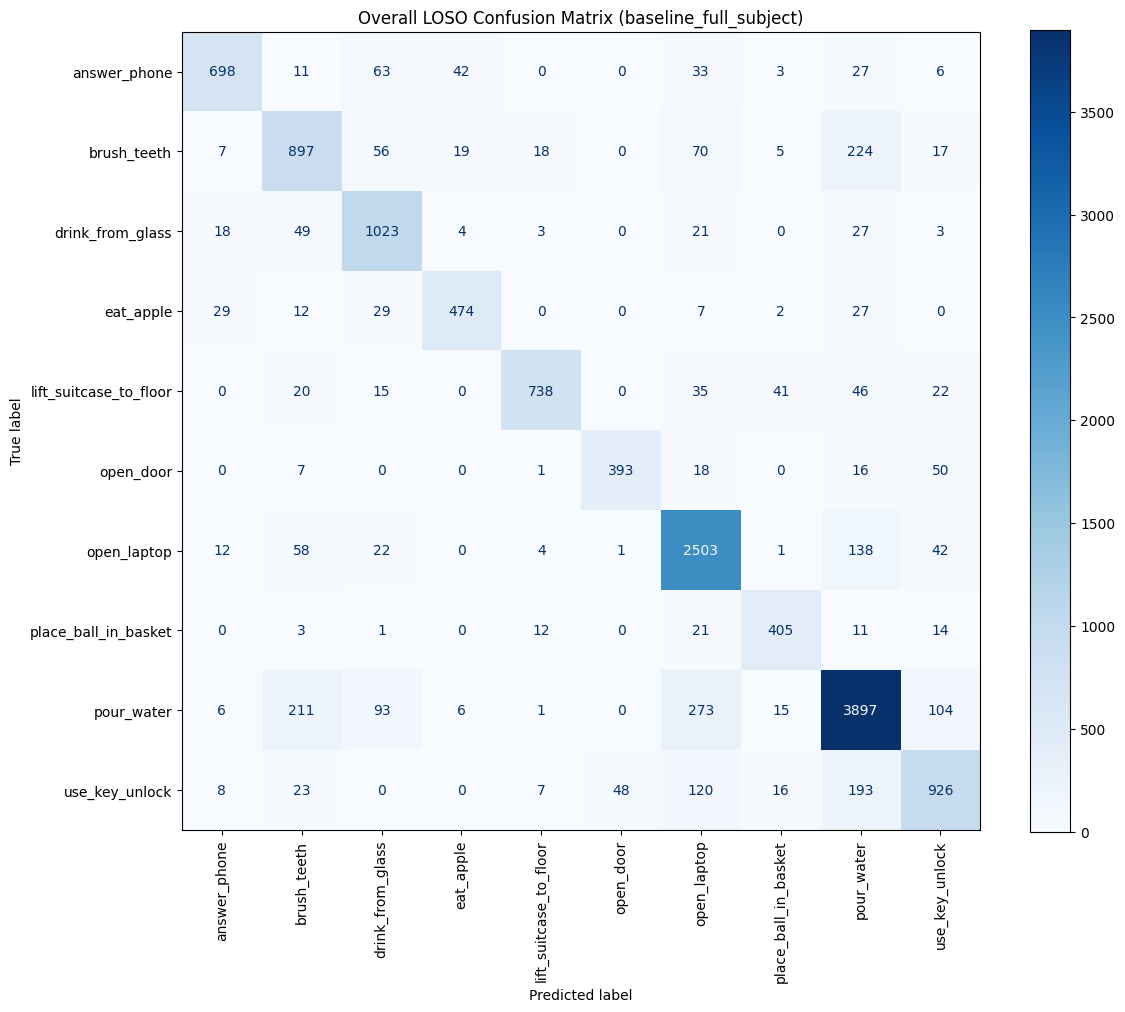

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Choose which prediction set to plot.
# Options: "baseline_full_subject", "baseline_remaining_reps_only", "adapted_remaining_reps"
CONFUSION_EVALUATION = "baseline_full_subject"

pred_df = fixed_run_out["all_predictions_df"].query("evaluation == @CONFUSION_EVALUATION").copy()
if pred_df.empty:
    raise ValueError(f"No predictions found for evaluation={CONFUSION_EVALUATION!r}")

y_true = pred_df["true_label_int"].to_numpy()
y_pred = pred_df["pred_label_int"].to_numpy()

label_map = (
    fixed_run_out["all_predictions_df"][["true_label_int", "true_label"]]
    .drop_duplicates()
    .sort_values("true_label_int")
)
class_names = label_map["true_label"].tolist()

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(len(class_names))
)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=True
)

plt.title(f"Overall LOSO Confusion Matrix ({CONFUSION_EVALUATION})")
plt.tight_layout()
plt.show()


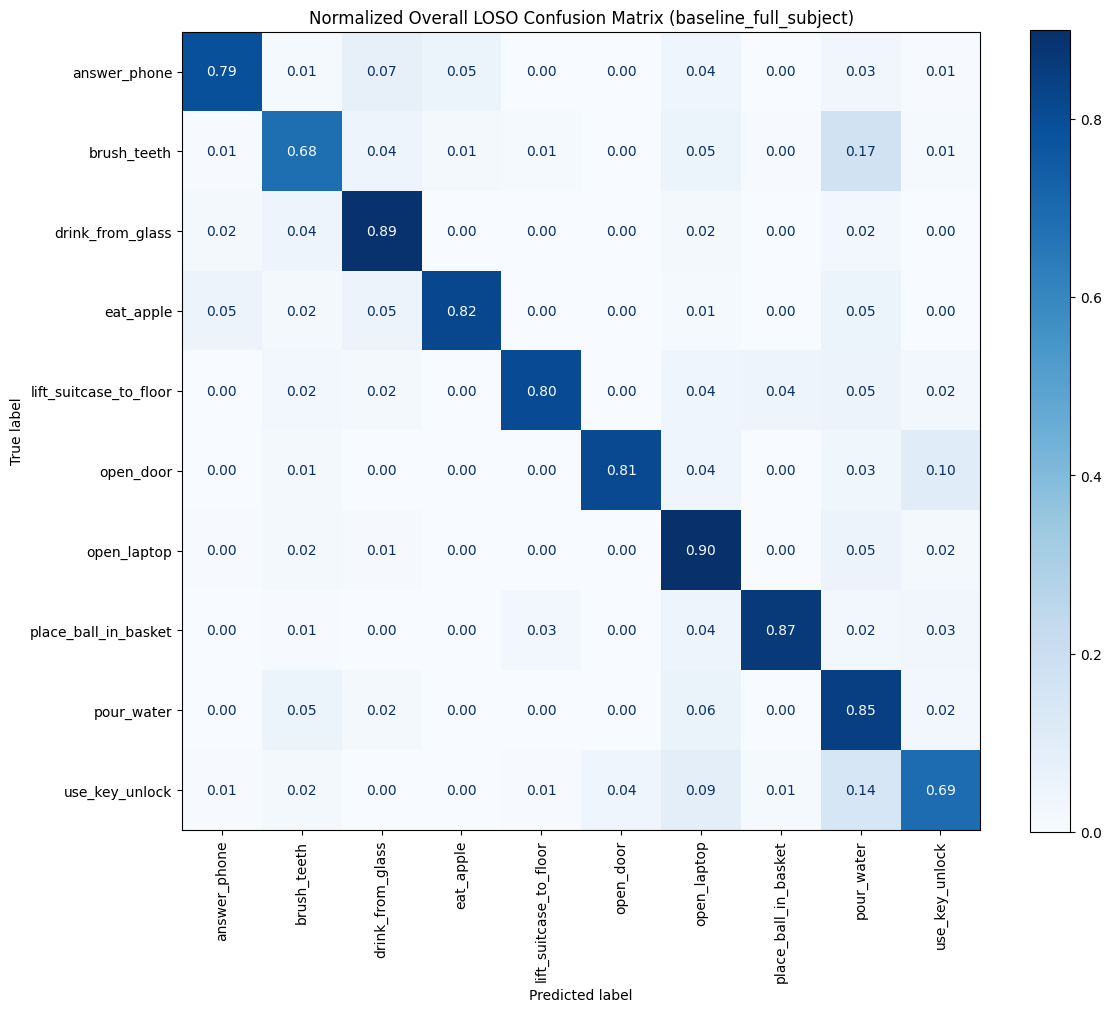

In [12]:
cm_norm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(len(class_names)),
    normalize="true"
)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=True,
    values_format=".2f"
)

plt.title(f"Normalized Overall LOSO Confusion Matrix ({CONFUSION_EVALUATION})")
plt.tight_layout()
plt.show()
